In [2]:
import statistics

from main import load_graph_and_communities, run_configured_sicp
from removal import count_communities_in_hedges_removal, remove_nodes


p = 0.2

temp_graph, communities = load_graph_and_communities("Geometry", tau=2, verbose=True)

all_nodes = set.union(*temp_graph.values())
N_ = len(all_nodes)
K = int(p * float(N_))
graph_comm = remove_nodes(temp_graph, count_communities_in_hedges_removal(temp_graph, communities, K))
print(len(graph_comm))

res = run_configured_sicp(graph_comm, 50)
print(statistics.mean(res.values()))
print(res)

Loaded dataset 'Geometry' (edge-labeled) with 1193 hyperedges and 21 communities
  communities sizes: min=1, max=137, avg=27.619
1142
455.622
{'133': 455, '150': 456, '477': 455.6, '10': 455.5, '278': 455.7, '499': 456.3, '366': 455.1, '221': 456, '557': 455.3, '228': 456.3, '81': 455.9, '367': 455.1, '242': 455.7, '380': 455.9, '219': 455.4, '224': 455.4, '428': 455.2, '275': 456, '236': 456.1, '216': 455, '24': 455.7, '533': 455.5, '83': 455.9, '480': 455.2, '164': 455.9, '463': 455, '473': 455.7, '527': 455.3, '113': 454.9, '158': 455.9, '156': 455, '270': 455.8, '180': 456, '524': 455.8, '563': 456.2, '348': 455.2, '446': 456.1, '305': 454.9, '511': 455.8, '478': 455.7, '38': 456.1, '13': 457.1, '359': 456.3, '125': 455.8, '170': 455.4, '144': 455.3, '572': 455.3, '574': 455.3, '67': 455.8, '187': 454.7}


In [3]:
import config

rows = []
for ds in set(config.EL_DATASETS.keys()).union(set(config.L_DATASETS)):
    g, c = load_graph_and_communities(ds, tau=None, verbose=False)
    N = len(set.union(*g.values()))
    M = len(g)
    rows.append((ds, N, M))

rows = sorted(rows, key=lambda x: x[0].lower())

dataset_w = max(len("Dataset"), *(len(ds) for ds, _, _ in rows))
n_w = max(len("N"), *(len(str(n)) for _, n, _ in rows))
m_w = max(len("M"), *(len(str(m)) for _, _, m in rows))

print(f"{'Dataset':<{dataset_w}} | {'N':>{n_w}} | {'M':>{m_w}}")
print(f"{'-' * dataset_w}-+-{'-' * n_w}-+-{'-' * m_w}")

for ds, n, m in rows:
    print(f"{ds:<{dataset_w}} | {n:>{n_w}} | {m:>{m_w}}")

Dataset                |    N |     M
-----------------------+------+------
Algebra                |  423 |  1268
Bars-Rev               | 1234 |  1194
contact-high-school    |  327 |  7818
contact-primary-school |  242 | 12704
Geometry               |  580 |  1193
Music-Rev              | 1106 |   694
Restaurants-Rev        |  565 |   601


Loaded dataset 'Geometry' (edge-labeled) with 1193 hyperedges and 21 communities
  communities sizes: min=1, max=137, avg=27.619


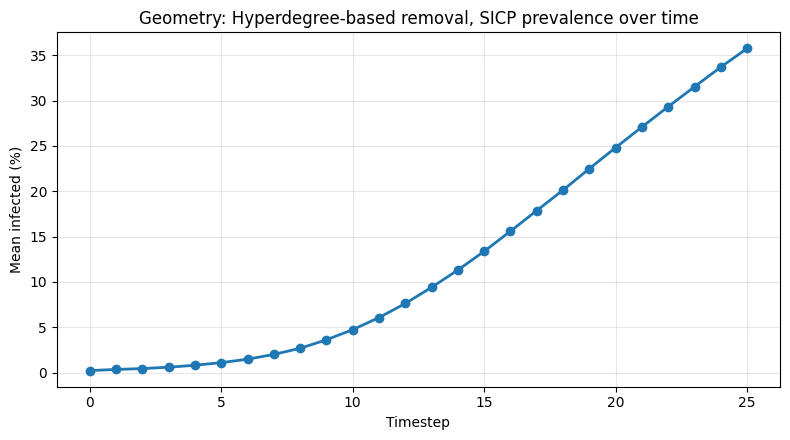

Removed nodes: 116 / 580 (20.0%)
Remaining nodes: 464


In [12]:
import matplotlib.pyplot as plt

from main import load_graph_and_communities, run_configured_sicp_intermediates
from removal import hyperdegree_based_removal, remove_nodes

# Simple setup: Geometry + hyperdegree-based removal
dataset = "Geometry"
p = 0.2
T = 25
runs = 10
seed_iterations = 50
rng_seed = 175
beta = 0.02

temp_graph, communities = load_graph_and_communities(dataset, tau=2, verbose=True)

all_nodes = set.union(*temp_graph.values())
N = len(all_nodes)
K = int(p * float(N))

graph_hdeg = remove_nodes(temp_graph, hyperdegree_based_removal(temp_graph, K))
remaining_nodes = len(set.union(*graph_hdeg.values()))

mean_infected_counts = run_configured_sicp_intermediates(
    graph_hdeg,
    seed_iterations=seed_iterations,
    beta=beta,
    T=T,
    runs=runs,
    rng_seed=rng_seed,
 )

infected_pct = [100.0 * x / remaining_nodes for x in mean_infected_counts]
timesteps = list(range(len(infected_pct)))

plt.figure(figsize=(8, 4.5))
plt.plot(timesteps, infected_pct, marker="o", linewidth=2)
plt.xlabel("Timestep")
plt.ylabel("Mean infected (%)")
plt.title("Geometry: Hyperdegree-based removal, SICP prevalence over time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Removed nodes: {K} / {N} ({100 * K / N:.1f}%)")
print(f"Remaining nodes: {remaining_nodes}")

Loaded dataset 'Geometry' (edge-labeled) with 1193 hyperedges and 21 communities
  communities sizes: min=1, max=137, avg=27.619
[1/27] p=0.05, strategy=count_communities_in_hedges, elapsed=0.0s
[2/27] p=0.05, strategy=ic_hedges_to_hdeg, elapsed=162.2s
[3/27] p=0.05, strategy=count_ic_hedges, elapsed=336.3s
[4/27] p=0.05, strategy=responsibility_weighted_hdeg, elapsed=475.2s
[5/27] p=0.05, strategy=filtered_hyperdegree, elapsed=611.4s
[6/27] p=0.05, strategy=avg_hyperedge_size, elapsed=748.5s
[7/27] p=0.05, strategy=hyperdegree, elapsed=926.4s
[8/27] p=0.05, strategy=degree, elapsed=1788.0s
[9/27] p=0.05, strategy=random, elapsed=1926.7s
[10/27] p=0.10, strategy=count_communities_in_hedges, elapsed=2130.7s
[11/27] p=0.10, strategy=ic_hedges_to_hdeg, elapsed=2240.0s
[12/27] p=0.10, strategy=count_ic_hedges, elapsed=2371.1s
[13/27] p=0.10, strategy=responsibility_weighted_hdeg, elapsed=3085.4s
[14/27] p=0.10, strategy=filtered_hyperdegree, elapsed=3172.2s
[15/27] p=0.10, strategy=avg_hyp

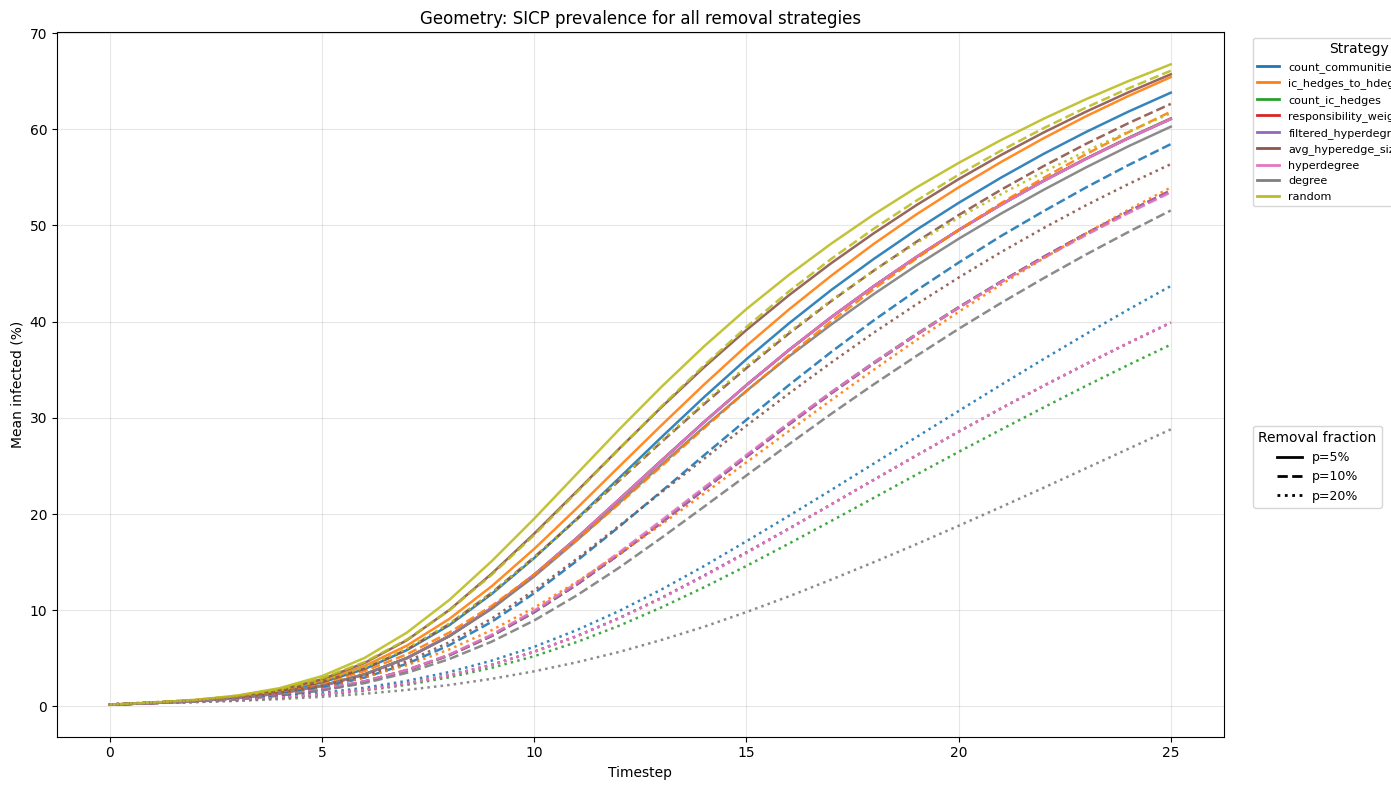

Done in 5203.2s
Raw data: outputs\geometry_all_strategies_prevalence.csv (702 rows)
Summary : outputs\geometry_all_strategies_summary.csv (27 rows)

Top results by final mean infected % (lower is better):
  p=5% | random                           final=66.74% auc=800.12
  p=5% | avg_hyperedge_size               final=65.71% auc=767.90
  p=5% | ic_hedges_to_hdeg                final=65.41% auc=745.86
  p=5% | count_communities_in_hedges      final=63.80% auc=720.21
  p=5% | count_ic_hedges                  final=61.12% auc=674.06
  p=5% | responsibility_weighted_hdeg     final=61.06% auc=673.85
  p=5% | filtered_hyperdegree             final=61.06% auc=673.85
  p=5% | hyperdegree                      final=61.06% auc=673.85
  p=5% | degree                           final=60.26% auc=663.07
  p=10% | random                           final=66.08% auc=772.87


In [13]:
import csv
import random
import time
import traceback
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from main import load_graph_and_communities, run_configured_sicp_intermediates
from removal import (
    avg_hyperedge_size_removal,
    count_communities_in_hedges_removal,
    count_ic_hedges,
    degree_based_removal,
    filtered_hyperdegree_removal,
    hyperdegree_based_removal,
    ic_hedges_to_hdeg,
    random_based_removal,
    remove_nodes,
    responsibility_weighted_hdeg_removal,
 )

dataset = "Geometry"
T = 25
runs = 10
seed_iterations = 20000
rng_seed = 175
beta = 0.02
p_values = [0.05, 0.10, 0.20]

out_dir = Path("outputs")
out_dir.mkdir(parents=True, exist_ok=True)
raw_file = out_dir / "geometry_all_strategies_prevalence.csv"
summary_file = out_dir / "geometry_all_strategies_summary.csv"
errors_file = out_dir / "geometry_all_strategies_errors.csv"

temp_graph, communities = load_graph_and_communities(dataset, tau=2, verbose=True)
all_nodes = set.union(*temp_graph.values())
N = len(all_nodes)

# name, function, requires_communities
strategies = [
    ("count_communities_in_hedges", count_communities_in_hedges_removal, True),
    ("ic_hedges_to_hdeg", ic_hedges_to_hdeg, True),
    ("count_ic_hedges", count_ic_hedges, True),
    ("responsibility_weighted_hdeg", responsibility_weighted_hdeg_removal, True),
    ("filtered_hyperdegree", filtered_hyperdegree_removal, True),
    ("avg_hyperedge_size", avg_hyperedge_size_removal, False),
    ("hyperdegree", hyperdegree_based_removal, False),
    ("degree", degree_based_removal, False),
    ("random", random_based_removal, False),
]

fieldnames = [
    "dataset",
    "strategy",
    "p",
    "K_removed",
    "remaining_nodes",
    "timestep",
    "mean_infected_count",
    "mean_infected_pct",
]

records = []
errors = []
start_time = time.time()

def write_records_checkpoint(path, rows):
    with path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

plt.figure(figsize=(14, 8))
ax = plt.gca()
strategy_colors = {name: plt.cm.tab10(i % 10) for i, (name, _, _) in enumerate(strategies)}
p_linestyle = {0.05: "-", 0.10: "--", 0.20: ":"}

total_jobs = len(p_values) * len(strategies)
job_idx = 0

for p in p_values:
    K = int(p * float(N))

    for strategy_name, strategy_fn, needs_communities in strategies:
        job_idx += 1
        elapsed = time.time() - start_time
        print(f"[{job_idx}/{total_jobs}] p={p:.2f}, strategy={strategy_name}, elapsed={elapsed:.1f}s")

        try:
            # Make random removal reproducible per (p, strategy).
            random.seed(10_000 + int(100 * p) + abs(hash(strategy_name)) % 1000)

            if needs_communities:
                nodes_to_remove = strategy_fn(temp_graph, communities, K)
            else:
                nodes_to_remove = strategy_fn(temp_graph, K)

            graph_removed = remove_nodes(temp_graph, nodes_to_remove)
            if not graph_removed:
                errors.append({
                    "p": p,
                    "strategy": strategy_name,
                    "error": "remove_nodes produced empty graph",
                })
                print(f"  skipped: empty graph after removal")
                continue

            remaining_nodes = len(set.union(*graph_removed.values()))
            if remaining_nodes == 0:
                errors.append({
                    "p": p,
                    "strategy": strategy_name,
                    "error": "zero remaining nodes",
                })
                print(f"  skipped: zero remaining nodes")
                continue

            mean_infected_counts = run_configured_sicp_intermediates(
                graph_removed,
                seed_iterations=seed_iterations,
                beta=beta,
                T=T,
                runs=runs,
                rng_seed=rng_seed,
            )

            # Guard against shape mismatches to avoid crashes on plotting/export.
            if len(mean_infected_counts) != T + 1:
                if len(mean_infected_counts) < T + 1:
                    tail = mean_infected_counts[-1] if mean_infected_counts else 0.0
                    mean_infected_counts = mean_infected_counts + [tail] * (T + 1 - len(mean_infected_counts))
                else:
                    mean_infected_counts = mean_infected_counts[: T + 1]

            infected_pct = [100.0 * x / remaining_nodes for x in mean_infected_counts]
            timesteps = list(range(T + 1))

            ax.plot(
                timesteps,
                infected_pct,
                linewidth=1.8,
                alpha=0.9,
                color=strategy_colors[strategy_name],
                linestyle=p_linestyle[p],
            )

            for t, mean_count, mean_pct in zip(timesteps, mean_infected_counts, infected_pct):
                records.append({
                    "dataset": dataset,
                    "strategy": strategy_name,
                    "p": p,
                    "K_removed": K,
                    "remaining_nodes": remaining_nodes,
                    "timestep": t,
                    "mean_infected_count": mean_count,
                    "mean_infected_pct": mean_pct,
                })

            # Checkpoint after each successful job so long runs are recoverable.
            write_records_checkpoint(raw_file, records)

        except Exception as exc:
            errors.append({
                "p": p,
                "strategy": strategy_name,
                "error": str(exc),
                "traceback": traceback.format_exc(limit=1).strip(),
            })
            print(f"  failed: {exc}")

ax.set_xlabel("Timestep")
ax.set_ylabel("Mean infected (%)")
ax.set_title("Geometry: SICP prevalence for all removal strategies")
ax.grid(True, alpha=0.3)

strategy_handles = [
    Line2D([0], [0], color=strategy_colors[name], lw=2, label=name)
    for name, _, _ in strategies
]
p_handles = [
    Line2D([0], [0], color="black", lw=2, linestyle=p_linestyle[p], label=f"p={int(100 * p)}%")
    for p in p_values
]

leg1 = ax.legend(handles=strategy_handles, title="Strategy", loc="upper left", bbox_to_anchor=(1.02, 1.00), fontsize=8)
ax.add_artist(leg1)
ax.legend(handles=p_handles, title="Removal fraction", loc="upper left", bbox_to_anchor=(1.02, 0.45), fontsize=9)

plt.tight_layout()
plt.show()

if records:
    write_records_checkpoint(raw_file, records)

summary_rows = []
if records:
    by_combo = {}
    for row in records:
        key = (row["strategy"], row["p"])
        by_combo.setdefault(key, []).append(row)

    for (strategy_name, p), rows in by_combo.items():
        rows_sorted = sorted(rows, key=lambda r: r["timestep"])
        final = rows_sorted[-1]
        auc = sum(r["mean_infected_pct"] for r in rows_sorted)
        summary_rows.append({
            "dataset": dataset,
            "strategy": strategy_name,
            "p": p,
            "K_removed": final["K_removed"],
            "remaining_nodes": final["remaining_nodes"],
            "final_mean_infected_count": final["mean_infected_count"],
            "final_mean_infected_pct": final["mean_infected_pct"],
            "auc_mean_infected_pct": auc,
        })

    summary_rows = sorted(summary_rows, key=lambda r: (r["p"], -r["final_mean_infected_pct"]))

    summary_fields = [
        "dataset",
        "strategy",
        "p",
        "K_removed",
        "remaining_nodes",
        "final_mean_infected_count",
        "final_mean_infected_pct",
        "auc_mean_infected_pct",
    ]
    with summary_file.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=summary_fields)
        writer.writeheader()
        writer.writerows(summary_rows)

if errors:
    error_fields = ["p", "strategy", "error", "traceback"]
    with errors_file.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=error_fields)
        writer.writeheader()
        writer.writerows(errors)

elapsed_total = time.time() - start_time
print(f"Done in {elapsed_total:.1f}s")
print(f"Raw data: {raw_file} ({len(records)} rows)")
if summary_rows:
    print(f"Summary : {summary_file} ({len(summary_rows)} rows)")
if errors:
    print(f"Errors  : {errors_file} ({len(errors)} rows)")

if summary_rows:
    print("\nTop results by final mean infected % (lower is better):")
    for row in summary_rows[:10]:
        print(
            f"  p={int(100 * row['p'])}% | {row['strategy']:<32} "
            f"final={row['final_mean_infected_pct']:.2f}% "
            f"auc={row['auc_mean_infected_pct']:.2f}"
        )

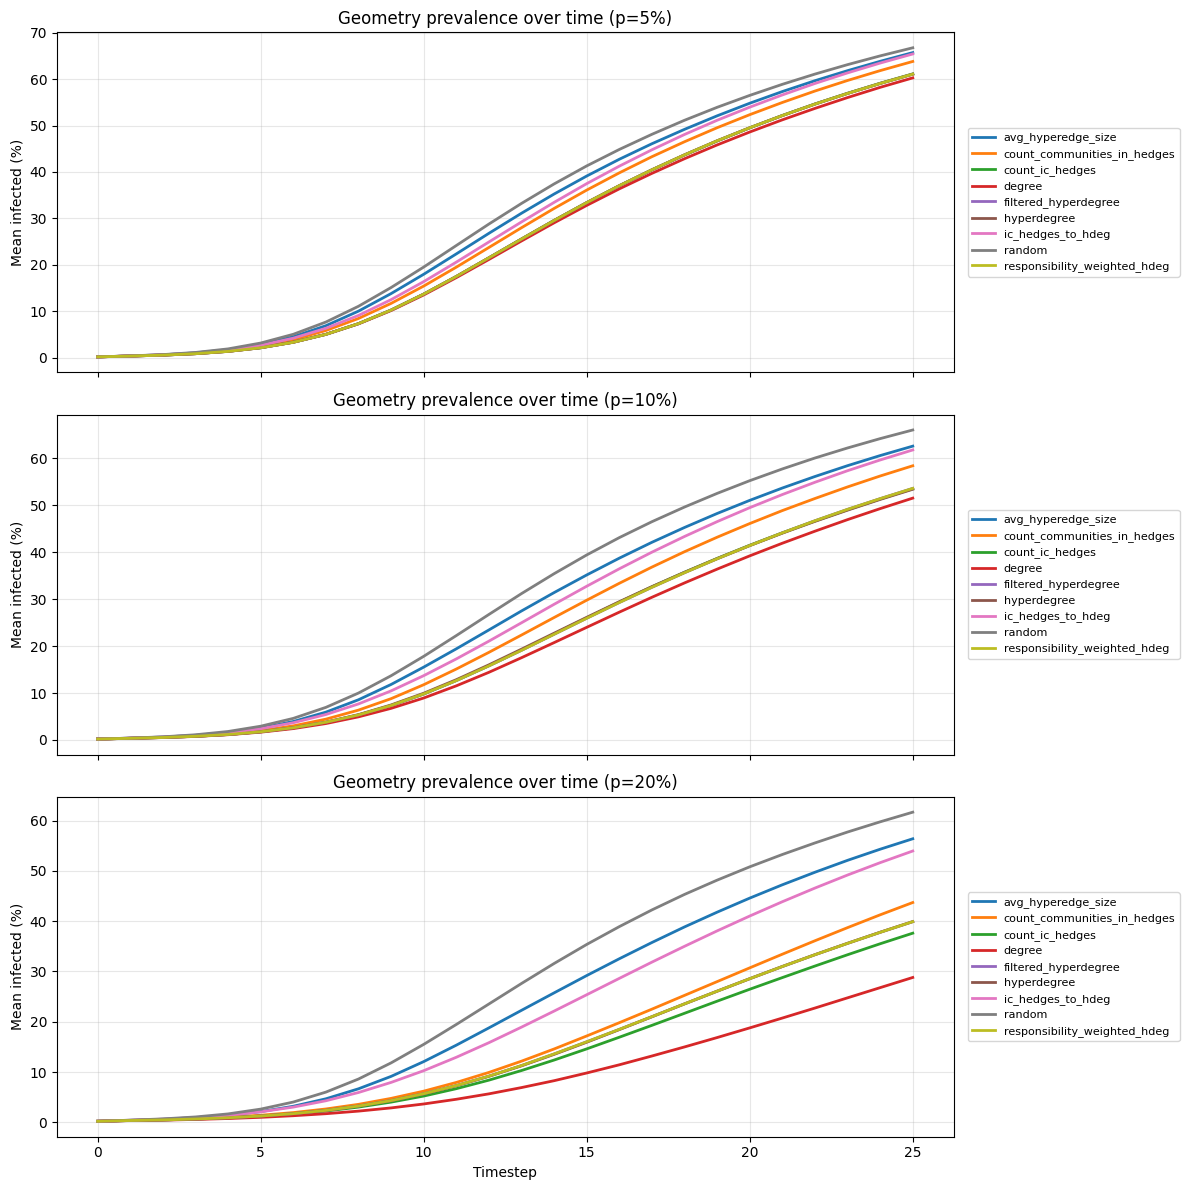

In [14]:
from collections import defaultdict
from pathlib import Path

import csv
import matplotlib.pyplot as plt

raw_file = Path("outputs") / "geometry_all_strategies_prevalence.csv"
if not raw_file.exists():
    raise FileNotFoundError(f"Could not find {raw_file}. Run the simulation/export cell first.")

rows = []
with raw_file.open("r", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for r in reader:
        rows.append(
            {
                "strategy": r["strategy"],
                "p": float(r["p"]),
                "timestep": int(r["timestep"]),
                "mean_infected_pct": float(r["mean_infected_pct"]),
            }
        )

if not rows:
    raise ValueError("CSV file is empty: nothing to plot.")

# Group by p, then by strategy
by_p = defaultdict(lambda: defaultdict(list))
for r in rows:
    by_p[r["p"]][r["strategy"]].append((r["timestep"], r["mean_infected_pct"]))

# Sort each strategy series by timestep
for p in by_p:
    for strategy in by_p[p]:
        by_p[p][strategy] = sorted(by_p[p][strategy], key=lambda x: x[0])

# One subplot per p-value
p_values = sorted(by_p.keys())
fig, axes = plt.subplots(nrows=len(p_values), ncols=1, figsize=(12, 4 * len(p_values)), sharex=True)
if len(p_values) == 1:
    axes = [axes]

for ax, p in zip(axes, p_values):
    strategies = sorted(by_p[p].keys())
    for strategy in strategies:
        ts = [x[0] for x in by_p[p][strategy]]
        ys = [x[1] for x in by_p[p][strategy]]
        ax.plot(ts, ys, linewidth=2, label=strategy)

    ax.set_title(f"Geometry prevalence over time (p={int(100 * p)}%)")
    ax.set_ylabel("Mean infected (%)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8)

axes[-1].set_xlabel("Timestep")
plt.tight_layout()
plt.show()

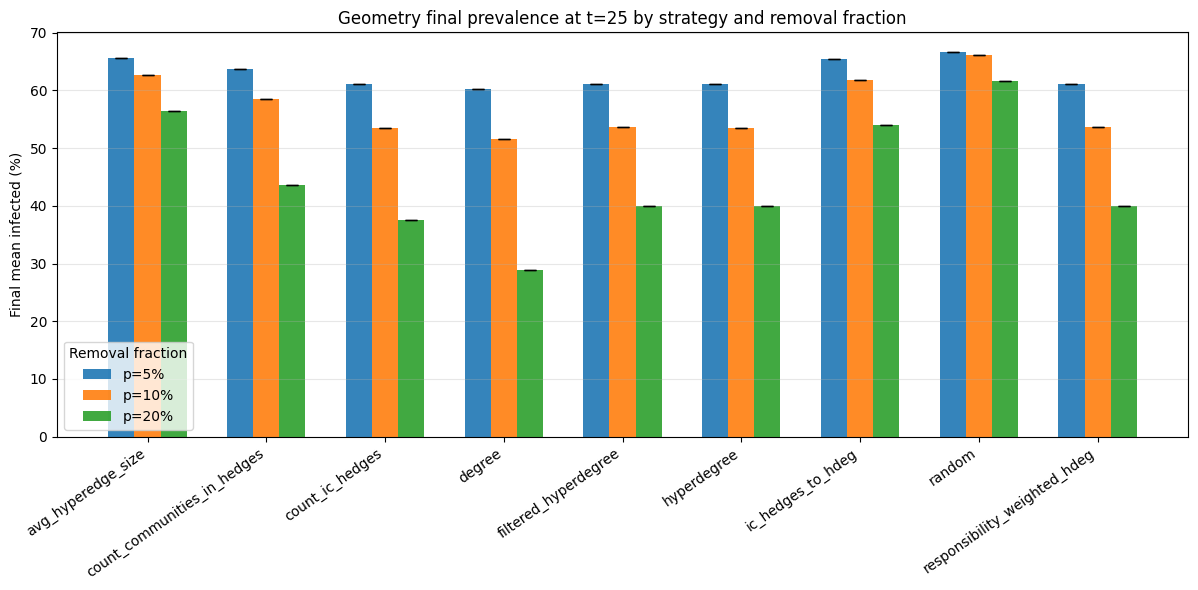

Final prevalence summary (%):

p=5%
  avg_hyperedge_size               mean= 65.71  sd=  0.00  n=1
  count_communities_in_hedges      mean= 63.80  sd=  0.00  n=1
  count_ic_hedges                  mean= 61.12  sd=  0.00  n=1
  degree                           mean= 60.26  sd=  0.00  n=1
  filtered_hyperdegree             mean= 61.06  sd=  0.00  n=1
  hyperdegree                      mean= 61.06  sd=  0.00  n=1
  ic_hedges_to_hdeg                mean= 65.41  sd=  0.00  n=1
  random                           mean= 66.74  sd=  0.00  n=1
  responsibility_weighted_hdeg     mean= 61.06  sd=  0.00  n=1

p=10%
  avg_hyperedge_size               mean= 62.63  sd=  0.00  n=1
  count_communities_in_hedges      mean= 58.45  sd=  0.00  n=1
  count_ic_hedges                  mean= 53.54  sd=  0.00  n=1
  degree                           mean= 51.55  sd=  0.00  n=1
  filtered_hyperdegree             mean= 53.63  sd=  0.00  n=1
  hyperdegree                      mean= 53.44  sd=  0.00  n=1
  ic_hedges_

In [15]:
from collections import defaultdict
from pathlib import Path

import csv
import math
import matplotlib.pyplot as plt
import numpy as np

raw_file = Path("outputs") / "geometry_all_strategies_prevalence.csv"
if not raw_file.exists():
    raise FileNotFoundError(f"Could not find {raw_file}. Run the simulation/export cell first.")

rows = []
with raw_file.open("r", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for r in reader:
        rows.append(
            {
                "strategy": r["strategy"],
                "p": float(r["p"]),
                "timestep": int(r["timestep"]),
                "mean_infected_pct": float(r["mean_infected_pct"]),
            }
        )

if not rows:
    raise ValueError("CSV file is empty: nothing to plot.")

# Determine final timestep from the file.
final_t = max(r["timestep"] for r in rows)
final_rows = [r for r in rows if r["timestep"] == final_t]

# Collect all final values per (p, strategy). If you reran/merged files and have duplicates,
# this will compute a real error bar; otherwise n=1 and error bar is 0.
vals = defaultdict(list)
for r in final_rows:
    vals[(r["p"], r["strategy"])].append(r["mean_infected_pct"] )

p_values = sorted({k[0] for k in vals.keys()})
strategies = sorted({k[1] for k in vals.keys()})

x = np.arange(len(strategies))
width = 0.22 if len(p_values) <= 3 else 0.8 / len(p_values)

fig, ax = plt.subplots(figsize=(max(12, 0.9 * len(strategies) + 4), 6))

for i, p in enumerate(p_values):
    means = []
    yerr = []
    n_rep = []
    for s in strategies:
        arr = vals.get((p, s), [])
        if arr:
            mu = float(np.mean(arr))
            sd = float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0
            means.append(mu)
            yerr.append(sd)  # std-dev error bars
            n_rep.append(len(arr))
        else:
            means.append(np.nan)
            yerr.append(0.0)
            n_rep.append(0)

    offset = (i - (len(p_values) - 1) / 2.0) * width
    ax.bar(
        x + offset,
        means,
        width=width,
        yerr=yerr,
        capsize=4,
        alpha=0.9,
        label=f"p={int(100 * p)}%",
    )

ax.set_xticks(x)
ax.set_xticklabels(strategies, rotation=35, ha="right")
ax.set_ylabel("Final mean infected (%)")
ax.set_title(f"Geometry final prevalence at t={final_t} by strategy and removal fraction")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(title="Removal fraction")
plt.tight_layout()
plt.show()

# Compact table in output for exact reading
print("Final prevalence summary (%):")
for p in p_values:
    print(f"\np={int(100 * p)}%")
    for s in strategies:
        arr = vals.get((p, s), [])
        if arr:
            mu = float(np.mean(arr))
            sd = float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0
            print(f"  {s:<32} mean={mu:6.2f}  sd={sd:6.2f}  n={len(arr)}")
        else:
            print(f"  {s:<32} missing")

if all(len(v) <= 1 for v in vals.values()):
    print("\nNote: each (p, strategy) currently has one final value (n=1), so error bars are 0.")
    print("If you want non-zero empirical error bars, export replicate-level finals (e.g., per run/seed) and replot.")

p=5% | final delta=0.0000 pp | mean |delta|=0.0000 pp
p=10% | final delta=0.1910 pp | mean |delta|=0.0994 pp
p=20% | final delta=-0.0169 pp | mean |delta|=0.0220 pp


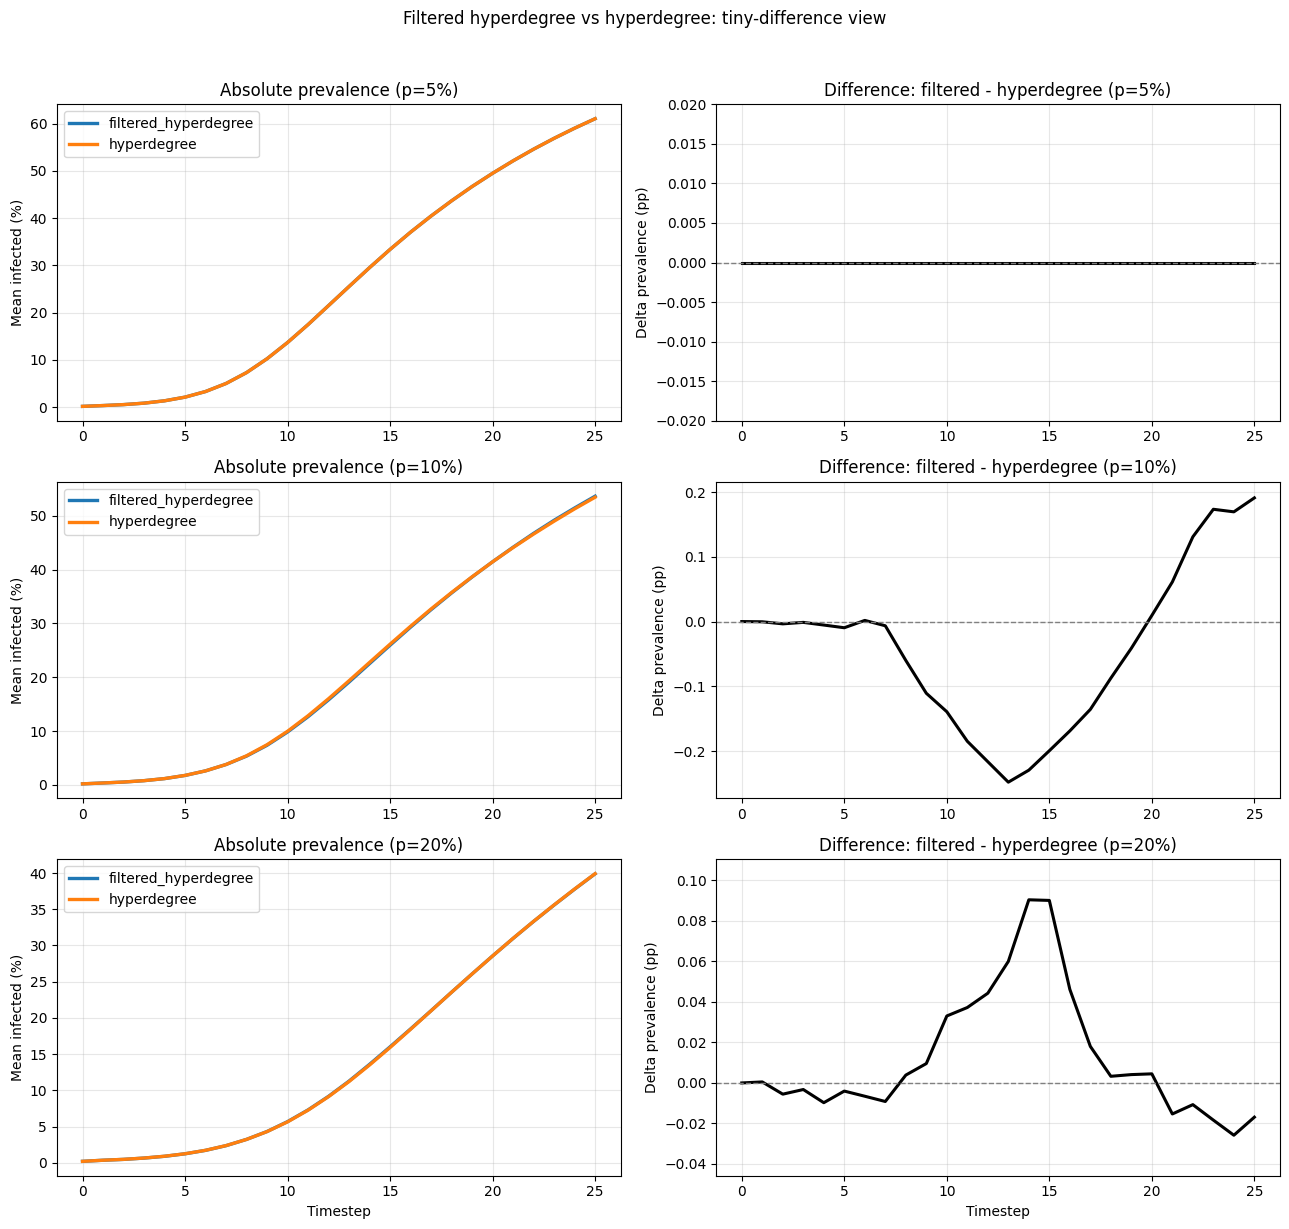

In [16]:
from collections import defaultdict
from pathlib import Path

import csv
import matplotlib.pyplot as plt

raw_file = Path("outputs") / "geometry_all_strategies_prevalence.csv"
if not raw_file.exists():
    raise FileNotFoundError(f"Could not find {raw_file}. Run the simulation/export cell first.")

target_strategies = {"filtered_hyperdegree", "hyperdegree"}
rows = []
with raw_file.open("r", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for r in reader:
        s = r["strategy"]
        if s in target_strategies:
            rows.append(
                {
                    "strategy": s,
                    "p": float(r["p"]),
                    "timestep": int(r["timestep"]),
                    "mean_infected_pct": float(r["mean_infected_pct"]),
                }
            )

if not rows:
    raise ValueError("No rows found for filtered_hyperdegree/hyperdegree in exported CSV.")

# series[p][strategy][t] = mean_infected_pct
series = defaultdict(lambda: defaultdict(dict))
for r in rows:
    series[r["p"]][r["strategy"]][r["timestep"]] = r["mean_infected_pct"]

p_values = sorted(series.keys())
fig, axes = plt.subplots(nrows=len(p_values), ncols=2, figsize=(13, 4 * len(p_values)), sharex=False)
if len(p_values) == 1:
    axes = [axes]

for row_idx, p in enumerate(p_values):
    s_filtered = series[p].get("filtered_hyperdegree", {})
    s_hdeg = series[p].get("hyperdegree", {})
    common_t = sorted(set(s_filtered.keys()).intersection(set(s_hdeg.keys())))
    if not common_t:
        raise ValueError(f"No common timesteps for p={p}.")

    y_filtered = [s_filtered[t] for t in common_t]
    y_hdeg = [s_hdeg[t] for t in common_t]
    y_delta = [a - b for a, b in zip(y_filtered, y_hdeg)]  # filtered - hyperdegree

    ax_abs = axes[row_idx][0]
    ax_delta = axes[row_idx][1]

    ax_abs.plot(common_t, y_filtered, label="filtered_hyperdegree", linewidth=2.4)
    ax_abs.plot(common_t, y_hdeg, label="hyperdegree", linewidth=2.4)
    ax_abs.set_title(f"Absolute prevalence (p={int(100 * p)}%)")
    ax_abs.set_ylabel("Mean infected (%)")
    ax_abs.grid(True, alpha=0.3)
    ax_abs.legend()

    ax_delta.plot(common_t, y_delta, color="black", linewidth=2.2)
    ax_delta.axhline(0.0, color="gray", linestyle="--", linewidth=1)
    ax_delta.set_title(f"Difference: filtered - hyperdegree (p={int(100 * p)}%)")
    ax_delta.set_ylabel("Delta prevalence (pp)")
    ax_delta.grid(True, alpha=0.3)

    # Tight y-axis around tiny deltas for visibility.
    dmin = min(y_delta)
    dmax = max(y_delta)
    pad = max(0.02, 0.1 * max(abs(dmin), abs(dmax), 1e-9))
    ax_delta.set_ylim(dmin - pad, dmax + pad)

    final_delta = y_delta[-1]
    mean_abs_delta = sum(abs(d) for d in y_delta) / len(y_delta)
    print(
        f"p={int(100 * p)}% | final delta={final_delta:.4f} pp | "
        f"mean |delta|={mean_abs_delta:.4f} pp"
    )

axes[-1][0].set_xlabel("Timestep")
axes[-1][1].set_xlabel("Timestep")
fig.suptitle("Filtered hyperdegree vs hyperdegree: tiny-difference view", y=1.02)
plt.tight_layout()
plt.show()